# Comprensión EDA — Análisis exploratorio y experimental de datos

## Objetivo

Este notebook realiza una exploración, caracterización, limpieza y análisis exploratorio de la base `Base_de_datos.xlsx`.

El análisis está orientado a:

- comprender la estructura y el significado de las variables;
- identificar tipos de datos y niveles de medición;
- detectar y unificar valores nulos;
- detectar inconsistencias y valores potencialmente inválidos;
- analizar las distribuciones univariables;
- estudiar relaciones bivariables y multivariables con la variable objetivo `Pago_atiempo`;
- proponer reglas de validación para etapas posteriores;
- identificar transformaciones y atributos derivados potencialmente útiles.

> **Criterio:** no se eliminan automáticamente todos los outliers. Se distingue entre valores claramente inválidos y valores extremos que podrían ser reales. Los casos dudosos se documentan para su validación posterior con conocimiento de negocio.

## 1. Importación de librerías y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Ruta portable desde la raíz del proyecto o desde src.
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / "Base_de_datos.xlsx").exists() else Path.cwd().parent
assert (ROOT / "Base_de_datos.xlsx").exists(), "Abrí el notebook desde la raíz o desde src"
df = pd.read_excel(ROOT / "Base_de_datos.xlsx")

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")

display(df.head())


Filas: 10,763
Columnas: 23


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,"3,692,160.000",10,42,Independiente,8000000,2500000,341296,88.768,695.000,10,5,0.000,"51,258.000","51,258.000",0.000,5,0,0,"908,526.000",Estable,1
1,4,2025-04-22 09:47:35,"840,000.000",6,60,Empleado,3000000,2000000,124876,95.228,789.000,3,1,0.000,"8,673.000","8,673.000",0.000,0,0,2,"939,017.000",Creciente,1
2,9,2026-01-08 12:22:40,"5,974,028.400",10,36,Independiente,4036000,829000,529554,47.614,740.000,4,5,0.000,"18,702.000","18,702.000",0.000,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,"1,671,240.000",6,48,Empleado,1524547,498000,252420,95.228,837.000,4,4,0.000,"15,782.000","15,782.000",0.000,3,0,0,"1,536,193.000",Creciente,1
4,9,2025-04-26 11:24:26,"2,781,636.000",11,44,Empleado,5000000,4000000,217037,95.228,771.000,4,6,0.000,"204,804.000","204,804.000",0.000,3,0,1,"933,473.000",Creciente,1


## 2. Exploración inicial

Primero se revisa la dimensión de la base, los primeros registros, los tipos de datos y la existencia de duplicados. Esto permite detectar problemas antes de comenzar el análisis estadístico.

In [2]:
print("Dimensiones:", df.shape)
print("\nTipos de datos:")
display(df.dtypes.to_frame("dtype"))

print("\nInformación general:")
df.info()

print("\nFilas duplicadas:", df.duplicated().sum())


Dimensiones: (10763, 23)

Tipos de datos:


,dtype
tipo_credito,int64
fecha_prestamo,datetime64[us]
capital_prestado,float64
plazo_meses,int64
edad_cliente,int64
tipo_laboral,str
salario_cliente,int64
total_otros_prestamos,int64
cuota_pactada,int64
puntaje,float64



Información general:
<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  int64         
 1   fecha_prestamo                 10763 non-null  datetime64[us]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  str           
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10757 non-null  float64       
 11  cant

### 2.1 Valores nulos y cardinalidad

Se calcula la cantidad y porcentaje de nulos por variable, junto con la cantidad de valores distintos. La cardinalidad ayuda a distinguir variables categóricas de variables numéricas y a detectar columnas con valores inesperados.

In [3]:
resumen_inicial = pd.DataFrame({
    "tipo_dato": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "porcentaje_nulos": (df.isna().mean() * 100).round(2),
    "valores_unicos": df.nunique(dropna=False),
})

display(resumen_inicial.sort_values("porcentaje_nulos", ascending=False))


,tipo_dato,nulos,porcentaje_nulos,valores_unicos
tendencia_ingresos,object,2932,27.240,47
promedio_ingresos_datacredito,float64,2930,27.220,5310
saldo_mora_codeudor,float64,590,5.480,5
saldo_principal,float64,405,3.760,8648
saldo_mora,float64,156,1.450,56
saldo_total,float64,156,1.450,8859
puntaje_datacredito,float64,6,0.060,316
salario_cliente,int64,0,0.000,1385
tipo_laboral,str,0,0.000,2
edad_cliente,int64,0,0.000,54


## 3. Caracterización de las variables

La siguiente clasificación es **semántica**, basada en los nombres y valores observados en la base:

| Variable | Tipo principal | Escala / naturaleza |
|---|---|---|
| `tipo_credito` | Categórica | nominal |
| `fecha_prestamo` | Fecha | temporal |
| `capital_prestado` | Numérica | continua |
| `plazo_meses` | Numérica | discreta |
| `edad_cliente` | Numérica | discreta |
| `tipo_laboral` | Categórica | nominal, dicotómica |
| `salario_cliente` | Numérica | continua |
| `total_otros_prestamos` | Numérica | continua |
| `cuota_pactada` | Numérica | continua |
| `puntaje` | Numérica | continua |
| `puntaje_datacredito` | Numérica | continua |
| `cant_creditosvigentes` | Numérica | discreta |
| `huella_consulta` | Numérica | discreta |
| `saldo_mora` | Numérica | continua |
| `saldo_total` | Numérica | continua |
| `saldo_principal` | Numérica | continua |
| `saldo_mora_codeudor` | Numérica | continua |
| `creditos_sectorFinanciero` | Numérica | discreta |
| `creditos_sectorCooperativo` | Numérica | discreta |
| `creditos_sectorReal` | Numérica | discreta |
| `promedio_ingresos_datacredito` | Numérica | continua |
| `tendencia_ingresos` | Categórica | nominal, politómica |
| `Pago_atiempo` | Categórica/binaria | dicotómica |

`Pago_atiempo` es la variable objetivo. `1` representa pago a tiempo y `0` representa pago no realizado a tiempo.

## 4. Unificación de valores nulos

En variables de texto se normalizan espacios y representaciones habituales de ausencia (`""`, `NA`, `N/A`, `NULL`, `None`, `?`, etc.) a `NaN`.

En esta base, la mayoría de los nulos ya vienen representados como `NaN`, pero esta etapa deja explícito el criterio de estandarización para futuras cargas de datos.

In [4]:
df_eda = df.copy()

# Normalización de cadenas
for col in df_eda.select_dtypes(include=["object", "string"]).columns:
    df_eda[col] = df_eda[col].apply(
        lambda x: x.strip() if isinstance(x, str) else x
    )
    df_eda[col] = df_eda[col].replace(
        ["", "NA", "N/A", "NULL", "null", "None", "none", "?", "-", "nan"],
        np.nan
    )

print("Nulos después de la unificación:")
display(
    pd.DataFrame({
        "nulos": df_eda.isna().sum(),
        "porcentaje": (df_eda.isna().mean() * 100).round(2)
    }).sort_values("nulos", ascending=False)
)


Nulos después de la unificación:


,nulos,porcentaje
tendencia_ingresos,2932,27.240
promedio_ingresos_datacredito,2930,27.220
saldo_mora_codeudor,590,5.480
saldo_principal,405,3.760
saldo_mora,156,1.450
saldo_total,156,1.450
puntaje_datacredito,6,0.060
salario_cliente,0,0.000
tipo_laboral,0,0.000
edad_cliente,0,0.000


## 5. Corrección de tipos e identificación de anomalías

Las reglas siguientes son **hipótesis exploratorias**, no dominios confirmados por negocio. Se conserva `df` intacto y se usa `df_eda` para este análisis de sensibilidad.

- `tipo_credito` se trata como categórica. El código `68` se marca para revisión, pero no se elimina solo por ser raro.
- Edad fuera de 18–100 y puntajes fuera de los rangos propuestos se convierten en nulos **solo en la vista exploratoria**, bajo supuestos que deben validarse.
- Un plazo mayor a 48 meses (por ejemplo, 90) se marca para revisión, pero podría ser válido: no se elimina por su rareza.
- `tendencia_ingresos`: se usa el dominio propuesto Creciente/Decreciente/Estable; debe confirmarse con el diccionario de datos.
- Montos y cantidades extremas no se eliminan automáticamente.

El modelo usa `create_features` de `ft_engineering.py`, no esta tabla exploratoria. En particular, no se aplican allí los límites provisionales de edad, plazo o puntaje de este análisis. Esto evita presentar supuestos exploratorios como reglas de producción validadas.


In [5]:
# Conversión explícita de fecha
df_eda["fecha_prestamo"] = pd.to_datetime(df_eda["fecha_prestamo"], errors="coerce")

# Códigos categóricos
df_eda["tipo_credito"] = df_eda["tipo_credito"].astype("category")
df_eda["tipo_laboral"] = df_eda["tipo_laboral"].astype("category")
df_eda["tendencia_ingresos"] = df_eda["tendencia_ingresos"].astype("category")
df_eda["Pago_atiempo"] = df_eda["Pago_atiempo"].astype("category")

# Rangos provisionales: análisis de sensibilidad, no reglas confirmadas.
df_eda.loc[~df_eda["edad_cliente"].between(18, 100), "edad_cliente"] = np.nan
# Los plazos largos se conservan hasta validar el dominio.
df_eda.loc[~df_eda["puntaje"].between(0, 100), "puntaje"] = np.nan
df_eda.loc[~df_eda["puntaje_datacredito"].between(0, 999), "puntaje_datacredito"] = np.nan

# La columna tipo_credito es categórica; el código 68 aparece como una categoría aislada.
# Se conserva y se reporta como anomalía para revisión; rareza no implica error.

# Limpiar categorías de tendencia que no pertenecen al dominio esperado
categorias_tendencia_validas = ["Creciente", "Decreciente", "Estable"]
mask_tendencia_invalida = (
    df_eda["tendencia_ingresos"].notna()
    & ~df_eda["tendencia_ingresos"].astype("string").isin(categorias_tendencia_validas)
)
df_eda.loc[mask_tendencia_invalida, "tendencia_ingresos"] = np.nan

print("Tipos de datos después de la corrección:")
display(df_eda.dtypes.to_frame("dtype"))


Tipos de datos después de la corrección:


,dtype
tipo_credito,category
fecha_prestamo,datetime64[us]
capital_prestado,float64
plazo_meses,int64
edad_cliente,float64
tipo_laboral,category
salario_cliente,int64
total_otros_prestamos,int64
cuota_pactada,int64
puntaje,float64


### 5.1 Nulos después de la limpieza exploratoria

Se cuantifica el efecto de los rangos provisionales y la normalización. Un aumento de nulos indica valores afectados por esos supuestos; no demuestra que los valores originales sean incorrectos.


In [6]:
resumen_limpio = pd.DataFrame({
    "nulos": df_eda.isna().sum(),
    "porcentaje_nulos": (df_eda.isna().mean() * 100).round(2),
})
display(resumen_limpio.sort_values("porcentaje_nulos", ascending=False))


,nulos,porcentaje_nulos
tendencia_ingresos,2990,27.780
promedio_ingresos_datacredito,2930,27.220
saldo_mora_codeudor,590,5.480
saldo_principal,405,3.760
saldo_mora,156,1.450
saldo_total,156,1.450
edad_cliente,150,1.390
puntaje,135,1.250
puntaje_datacredito,7,0.070
salario_cliente,0,0.000


## 6. Eliminación de variables irrelevantes

No se elimina ninguna variable en esta etapa únicamente por tener una alta cardinalidad o por ser numérica.

`fecha_prestamo` se conserva porque puede aportar información temporal. Los códigos de crédito se conservan como variables categóricas. La decisión de eliminar variables deberá apoyarse en conocimiento de negocio, fuga de información (*data leakage*), redundancia o desempeño posterior.

Por lo tanto, **no se identifica en la exploración una columna inequívocamente irrelevante que deba eliminarse de forma automática**.

## 7. Análisis univariable — estadística descriptiva

In [7]:
columnas_numericas = df_eda.select_dtypes(include=np.number).columns.tolist()

# Estadísticos clásicos
describe_num = df_eda[columnas_numericas].describe().T
describe_num["mediana"] = df_eda[columnas_numericas].median()
describe_num["moda"] = df_eda[columnas_numericas].mode().iloc[0]
describe_num["rango"] = describe_num["max"] - describe_num["min"]
describe_num["IQR"] = (
    df_eda[columnas_numericas].quantile(0.75)
    - df_eda[columnas_numericas].quantile(0.25)
)
describe_num["varianza"] = df_eda[columnas_numericas].var()
describe_num["skewness"] = df_eda[columnas_numericas].skew()
describe_num["kurtosis"] = df_eda[columnas_numericas].kurt()

display(describe_num.round(3))


,count,mean,std,min,25%,50%,75%,max,mediana,moda,rango,IQR,varianza,skewness,kurtosis
capital_prestado,"10,763.000","2,434,315.001","1,909,642.759","360,000.000","1,224,831.000","1,921,920.000","3,084,840.000","41,444,152.800","1,921,920.000","1,200,000.000","41,084,152.800","1,860,009.000","3,646,735,466,988.664",3.724,35.318
plazo_meses,"10,763.000",10.576,6.632,2.000,6.000,10.000,12.000,90.000,10.000,6.000,88.000,6.000,43.985,2.460,7.780
edad_cliente,"10,613.000",42.846,11.947,19.000,33.000,42.000,52.000,69.000,42.000,40.000,50.000,19.000,142.738,0.268,-0.861
salario_cliente,"10,763.000","17,216,431.460","355,476,717.603",0.000,"2,000,000.000","3,000,000.000","4,875,808.000","22,000,000,000.000","3,000,000.000","3,000,000.000","22,000,000,000.000","2,875,808.000","126,363,696,758,146,032.000",43.777,"2,211.230"
total_otros_prestamos,"10,763.000","6,238,869.649","118,418,316.941",0.000,"500,000.000","1,000,000.000","2,000,000.000","6,787,675,263.000","1,000,000.000","2,000,000.000","6,787,675,263.000","1,500,000.000","14,022,897,787,155,474.000",38.464,"1,719.281"
cuota_pactada,"10,763.000","243,617.407","210,493.695","23,944.000","121,041.500","182,863.000","287,833.500","3,816,752.000","182,863.000","205,990.000","3,792,808.000","166,792.000","44,307,595,469.581",3.793,26.651
puntaje,"10,628.000",92.468,11.823,0.051,95.228,95.228,95.228,95.228,95.228,95.228,95.177,0.000,139.778,-5.344,29.822
puntaje_datacredito,"10,756.000",780.864,104.607,0.000,757.000,791.000,825.000,999.000,791.000,0.000,999.000,68.000,"10,942.714",-5.651,39.599
cant_creditosvigentes,"10,763.000",5.727,3.977,0.000,3.000,5.000,8.000,62.000,5.000,4.000,62.000,5.000,15.818,1.798,8.623
huella_consulta,"10,763.000",4.229,3.065,0.000,2.000,4.000,6.000,29.000,4.000,2.000,29.000,4.000,9.392,1.487,3.999


### Interpretación de la distribución

`describe()` permite comparar escala, dispersión y asimetría. La media debe interpretarse junto con la mediana: cuando ambas difieren fuertemente, puede existir asimetría o influencia de valores extremos.

`skewness` positivo indica una cola hacia valores altos; valores negativos indican una cola hacia valores bajos. La curtosis permite evaluar la presencia de colas más o menos pesadas respecto de una distribución normal.

En las variables monetarias de esta base se espera especial atención a la asimetría y a valores extremos, por lo que además de la media deben considerarse mediana e IQR.

## 8. Histogramas y boxplots de variables numéricas

Los histogramas permiten observar forma y concentración de las distribuciones. Los boxplots permiten identificar observaciones alejadas del rango intercuartílico.

Los puntos considerados outliers por IQR **no se eliminan automáticamente**: un outlier estadístico no necesariamente es un dato inválido.

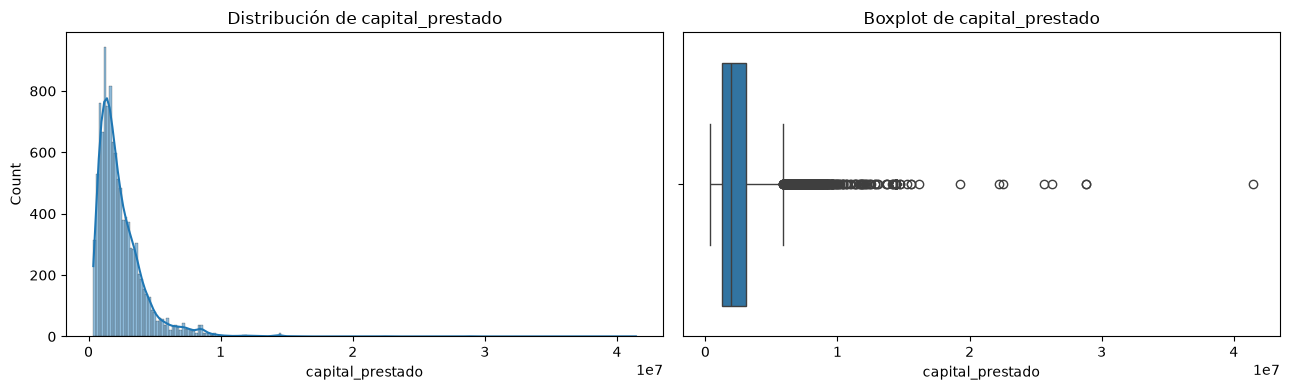

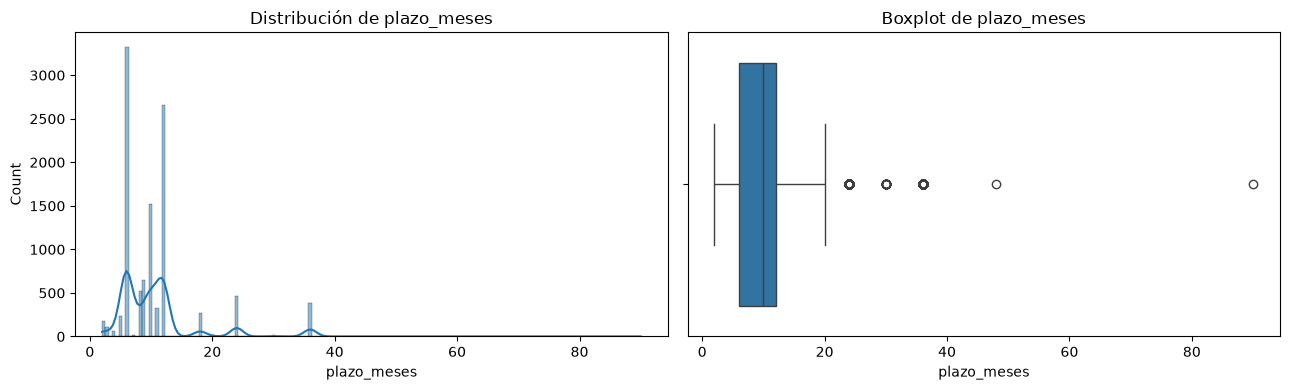

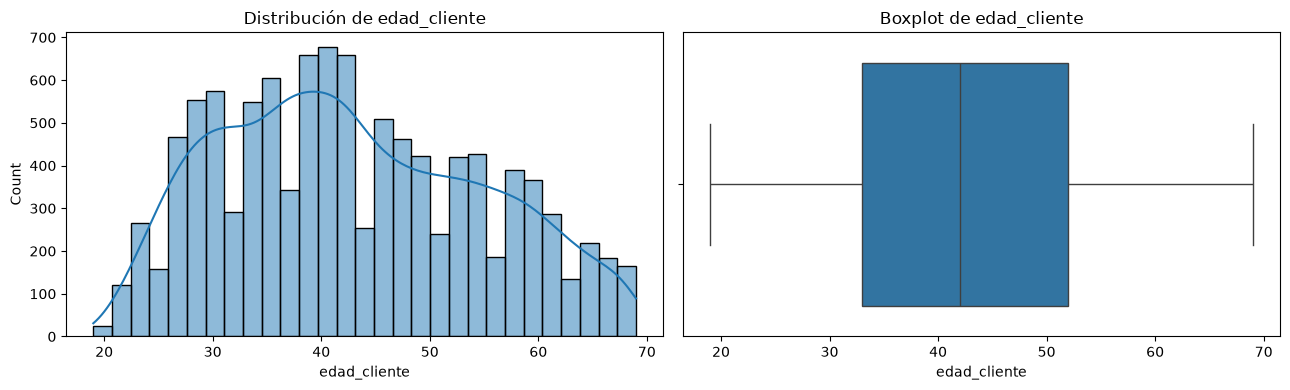

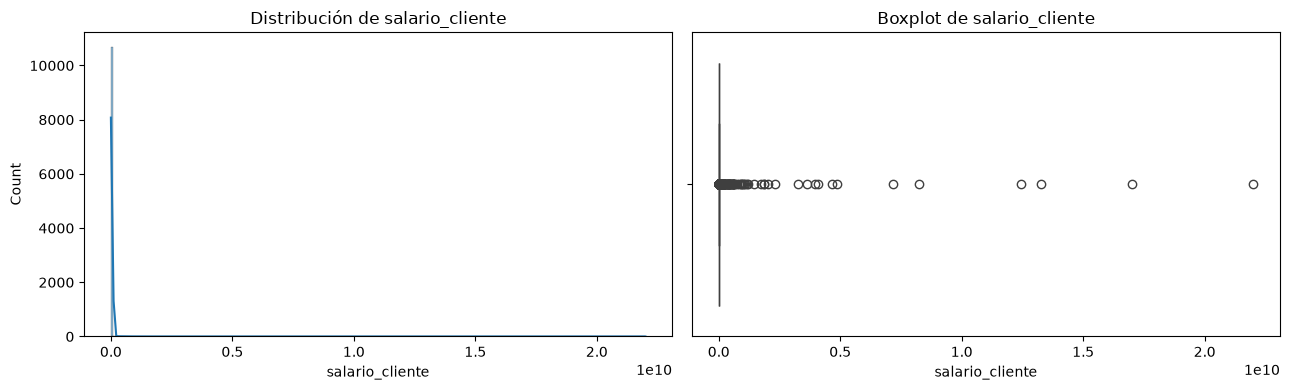

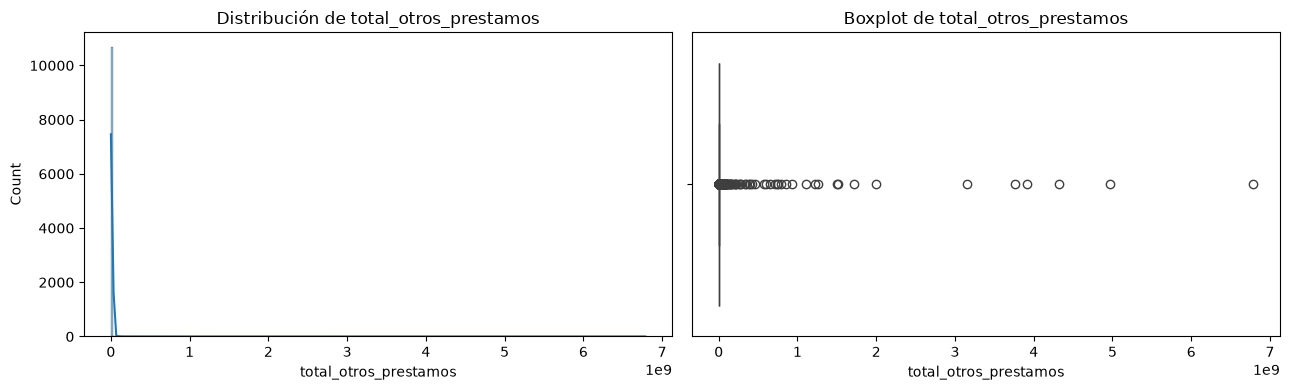

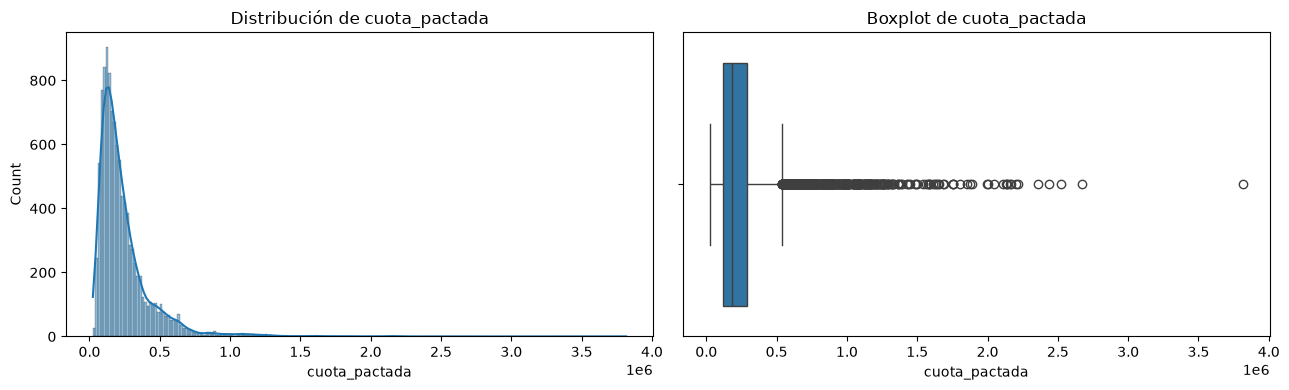

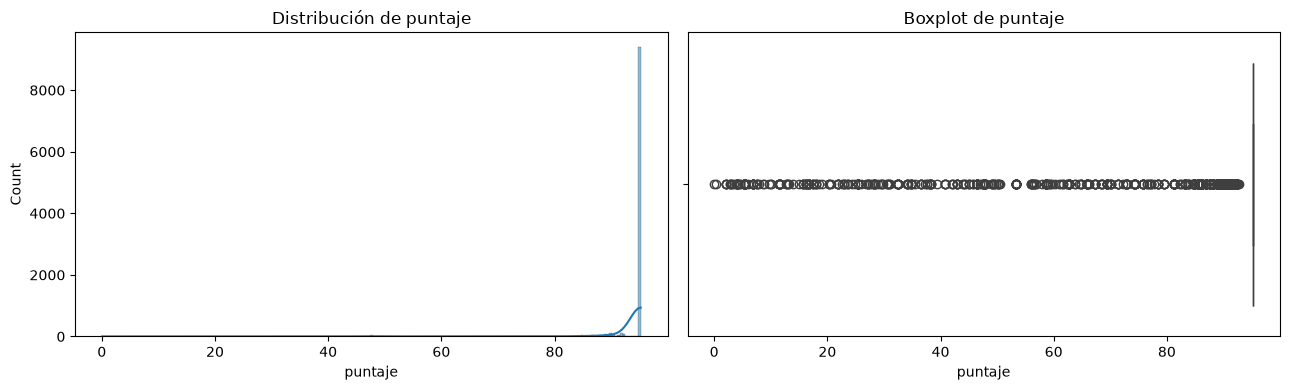

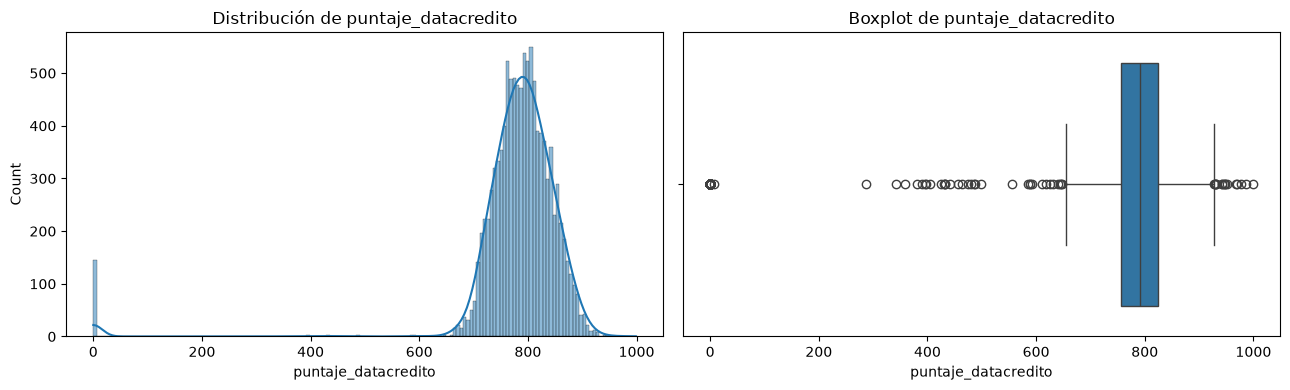

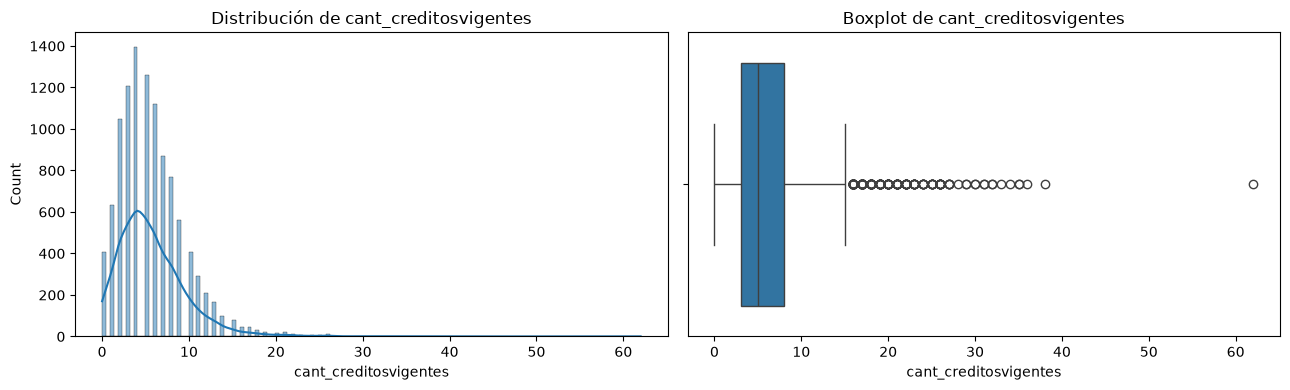

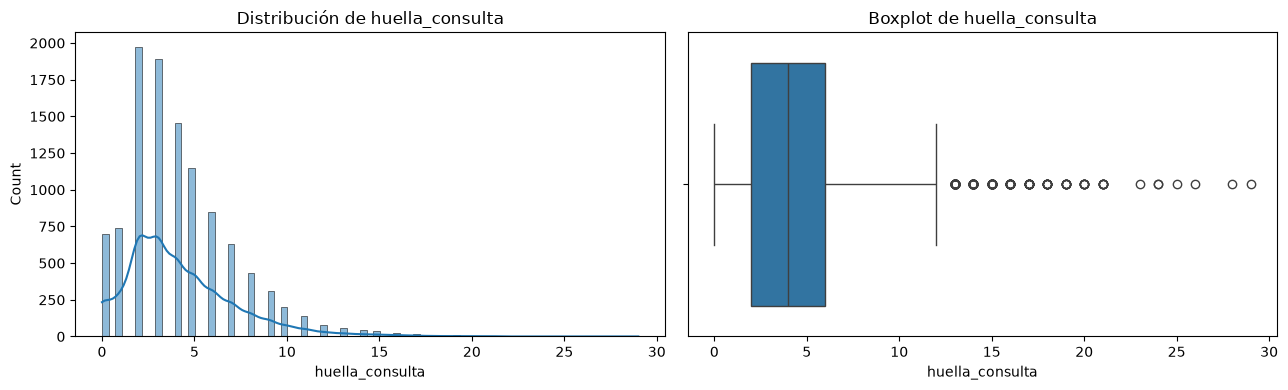

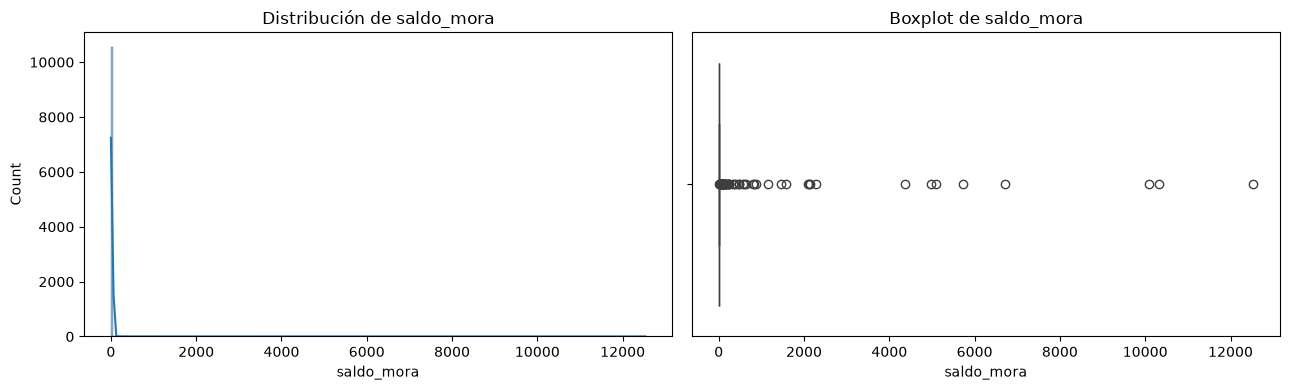

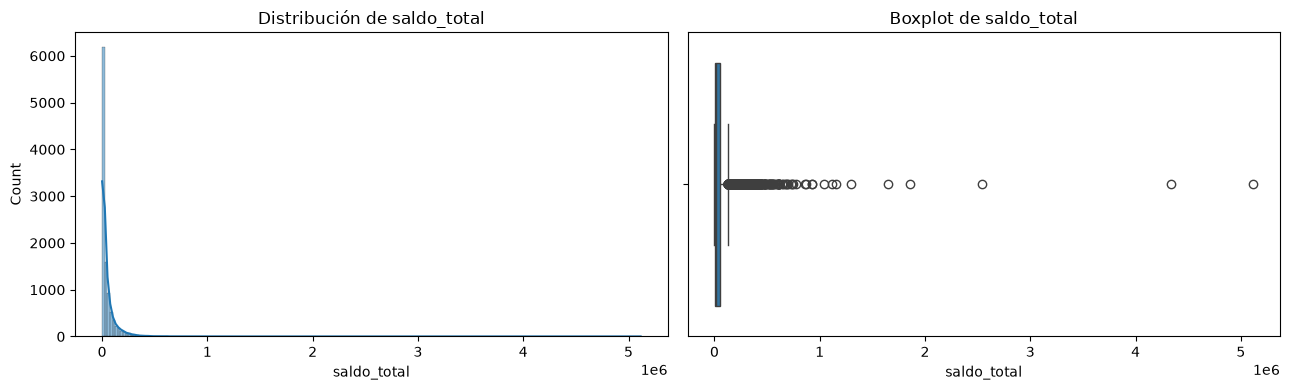

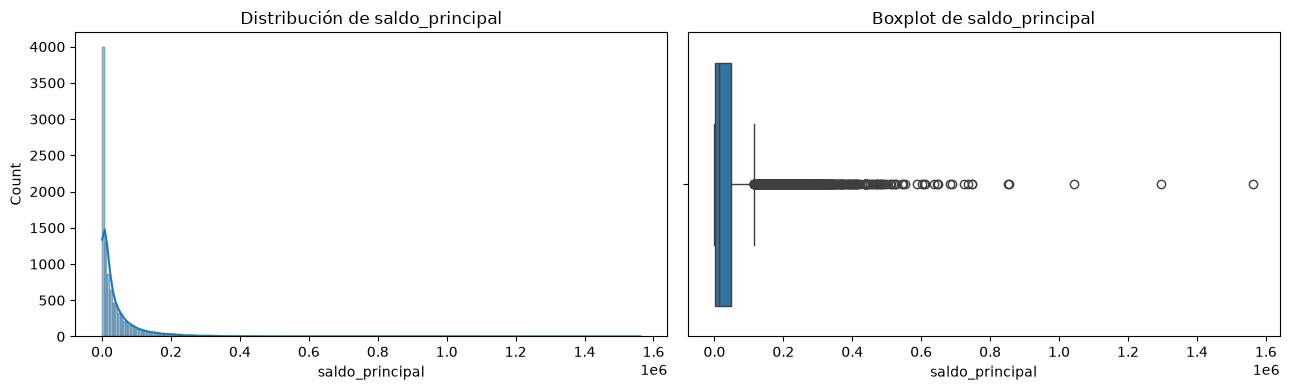

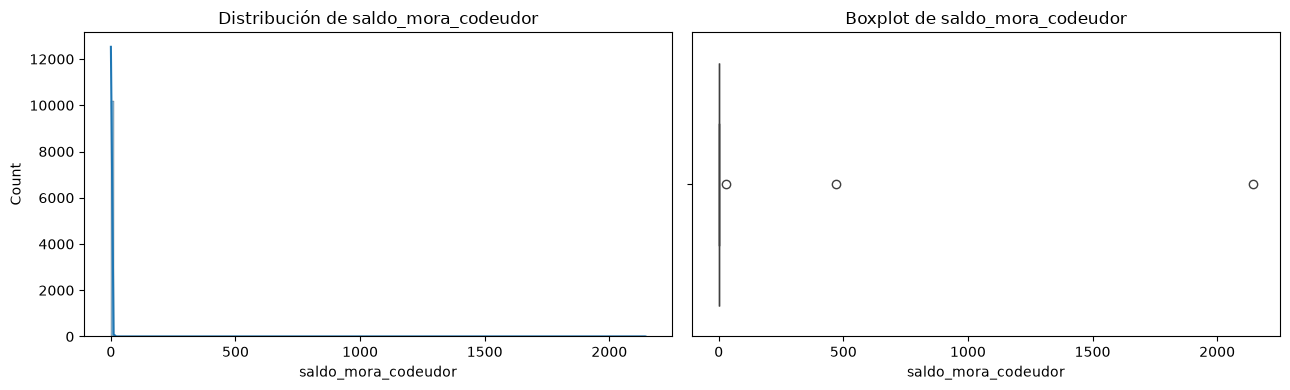

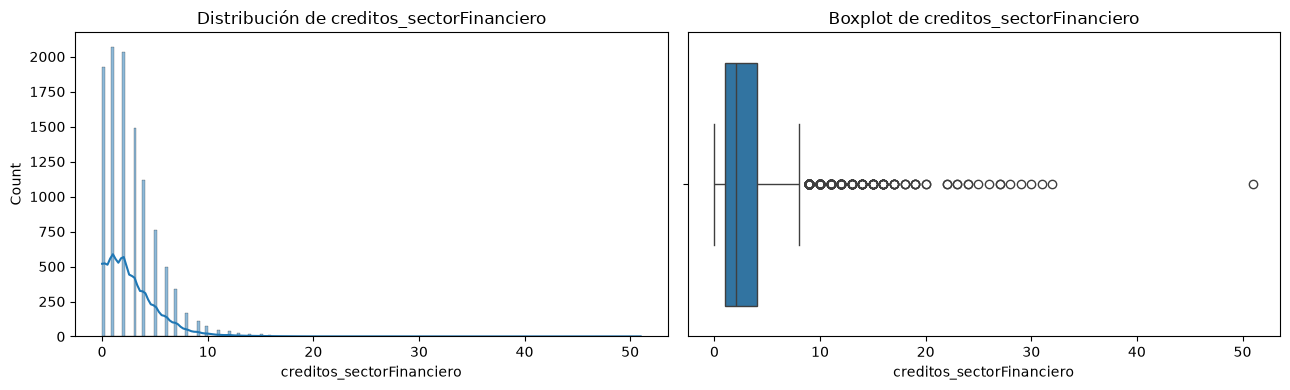

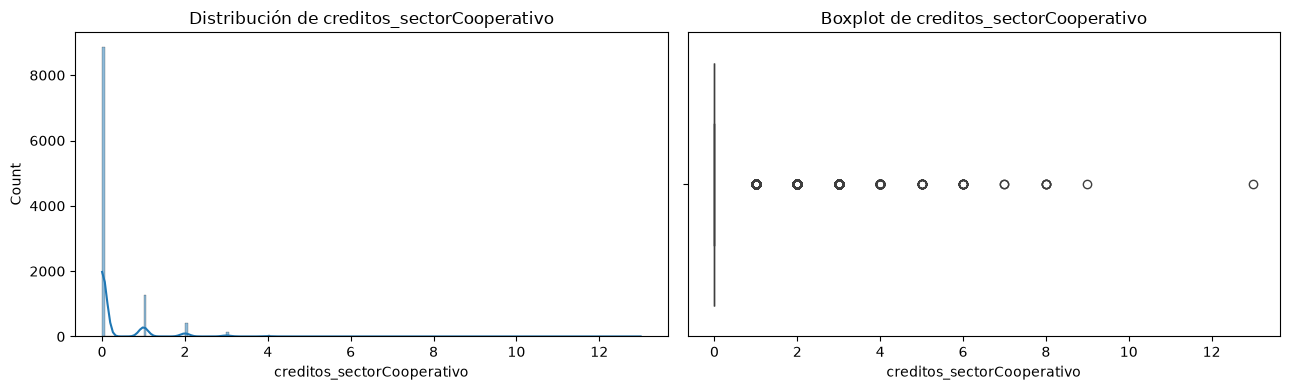

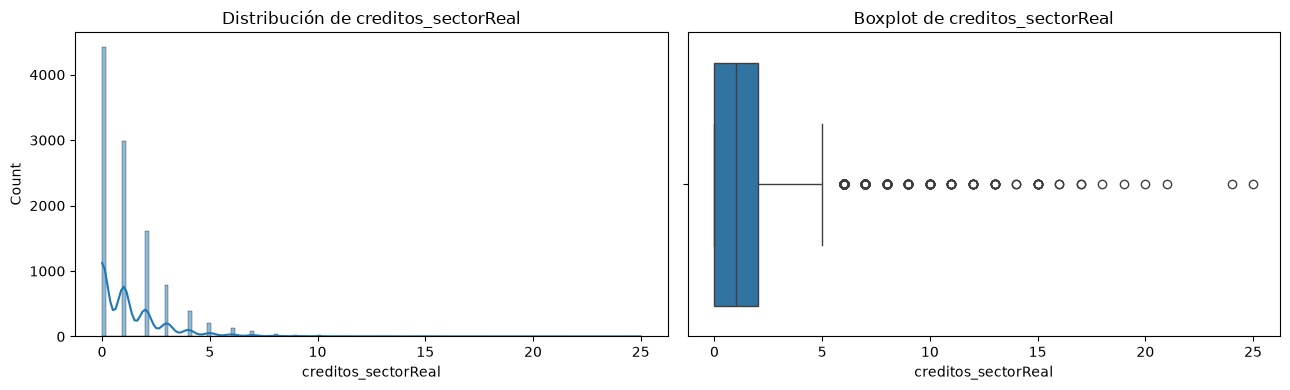

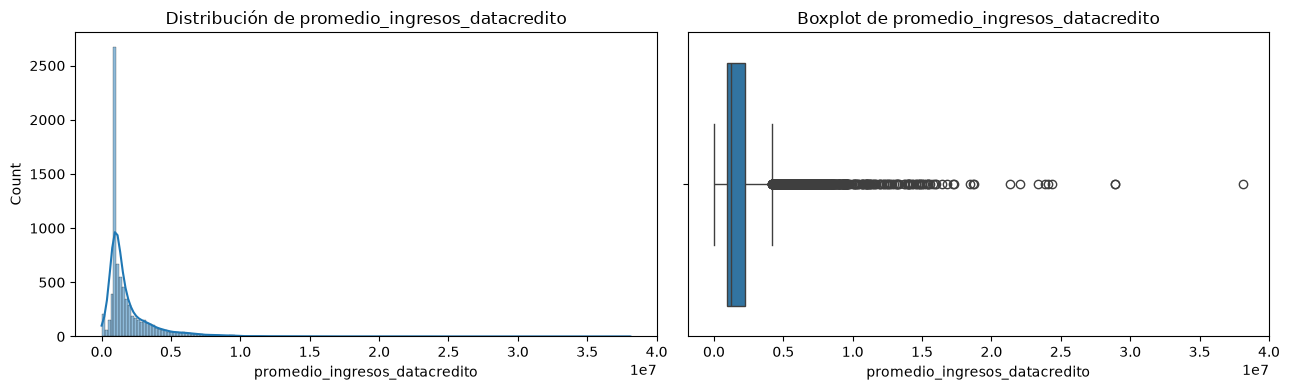

In [8]:
for col in columnas_numericas:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    sns.histplot(df_eda[col].dropna(), kde=True, ax=axes[0])
    axes[0].set_title(f"Distribución de {col}")
    axes[0].set_xlabel(col)

    sns.boxplot(x=df_eda[col], ax=axes[1])
    axes[1].set_title(f"Boxplot de {col}")
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()


## 9. Análisis univariable de variables categóricas

Se observan frecuencias absolutas y relativas. Esto permite detectar categorías dominantes, categorías extremadamente raras y posibles errores de codificación.


### tipo_credito


,frecuencia,porcentaje
tipo_credito,,
4,7747,71.980
9,2876,26.720
10,116,1.080
6,21,0.200
7,2,0.020
68,1,0.010


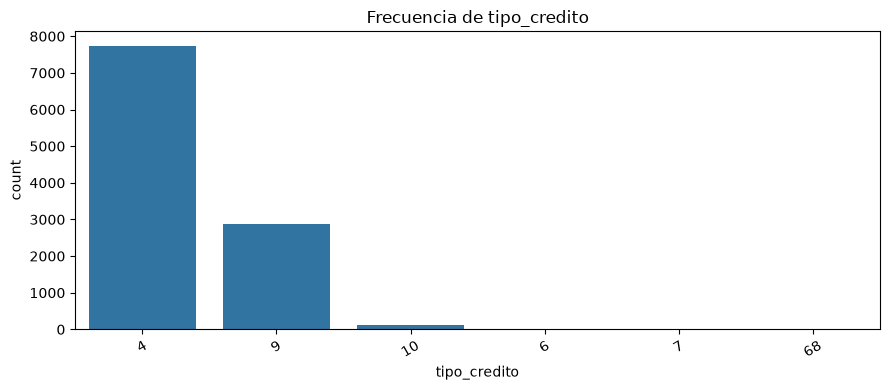


### tipo_laboral


,frecuencia,porcentaje
tipo_laboral,,
Empleado,6754,62.750
Independiente,4009,37.250


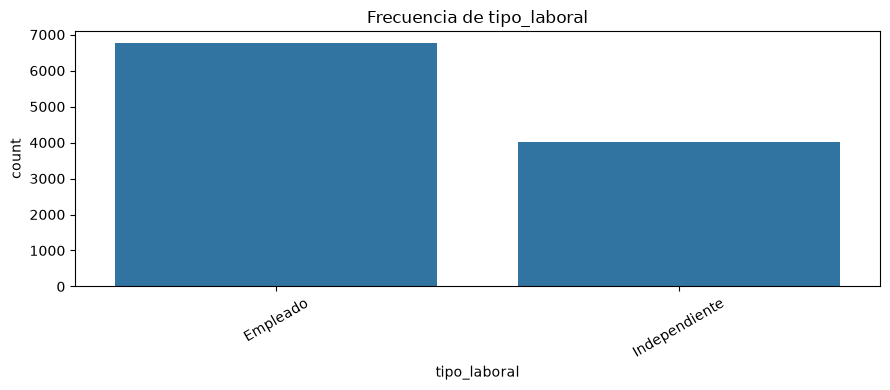


### tendencia_ingresos


,frecuencia,porcentaje
tendencia_ingresos,,
Creciente,5294,49.190
Sin dato,2990,27.780
Decreciente,1291,11.990
Estable,1188,11.040


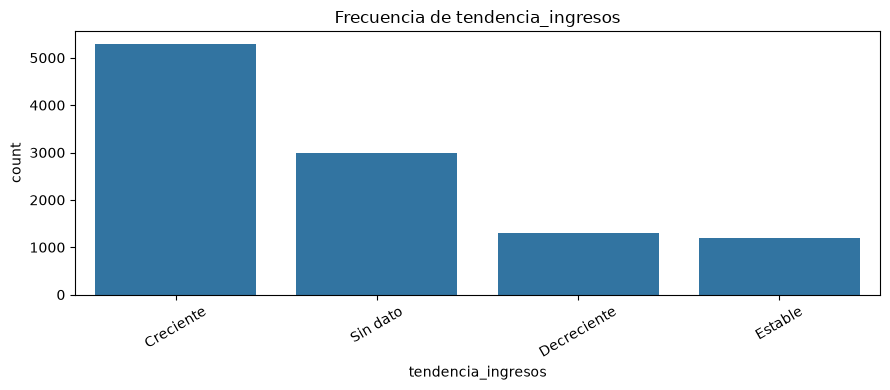


### Pago_atiempo


,frecuencia,porcentaje
Pago_atiempo,,
1,10252,95.250
0,511,4.750


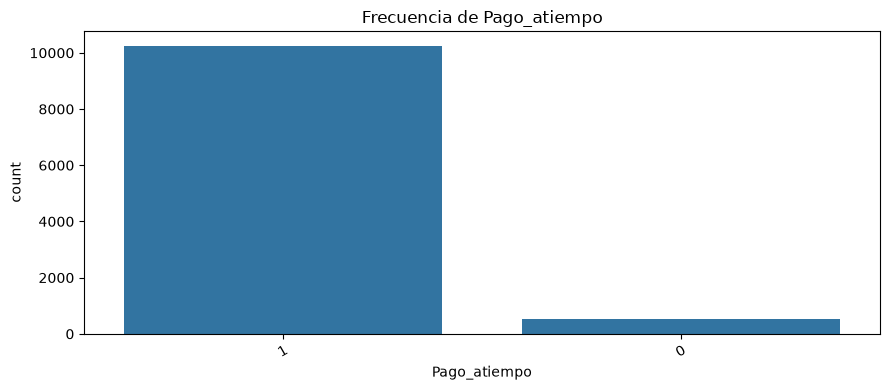

In [9]:
columnas_categoricas = ["tipo_credito", "tipo_laboral", "tendencia_ingresos", "Pago_atiempo"]
for col in columnas_categoricas:
    # Todos los rótulos son texto, incluidos los faltantes: evita mezclar float/str.
    labels = df_eda[col].astype("string").fillna("Sin dato")
    tabla = labels.value_counts(dropna=False).to_frame("frecuencia")
    tabla["porcentaje"] = (tabla["frecuencia"] / len(df_eda) * 100).round(2)
    print(f"\n### {col}")
    display(tabla)
    plt.figure(figsize=(9, 4))
    sns.countplot(x=labels, order=tabla.index.tolist())
    plt.title(f"Frecuencia de {col}")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


### 9.1 Variable objetivo

`Pago_atiempo` es dicotómica y presenta un claro desbalance: la categoría de pago a tiempo es mucho más frecuente que la de pago no realizado a tiempo.

Esto debe considerarse en la etapa de modelado, porque una métrica como accuracy puede resultar engañosa ante clases desbalanceadas. Será recomendable evaluar métricas como precisión, recall, F1 y ROC-AUC/PR-AUC según el objetivo del proyecto.

In [10]:
objetivo = df_eda["Pago_atiempo"].value_counts().sort_index()
print(objetivo)
print("\nPorcentajes:")
display((objetivo / objetivo.sum() * 100).round(2).to_frame("porcentaje"))


Pago_atiempo
0      511
1    10252
Name: count, dtype: int64

Porcentajes:


,porcentaje
Pago_atiempo,
0,4.750
1,95.250


## 10. Análisis bivariable respecto de `Pago_atiempo`

Se comparan las distribuciones de las variables numéricas entre quienes pagan a tiempo y quienes no. También se estudian las variables categóricas mediante proporciones dentro de cada grupo objetivo.

La interpretación debe centrarse en diferencias de distribución y no solamente en diferencias de medias.

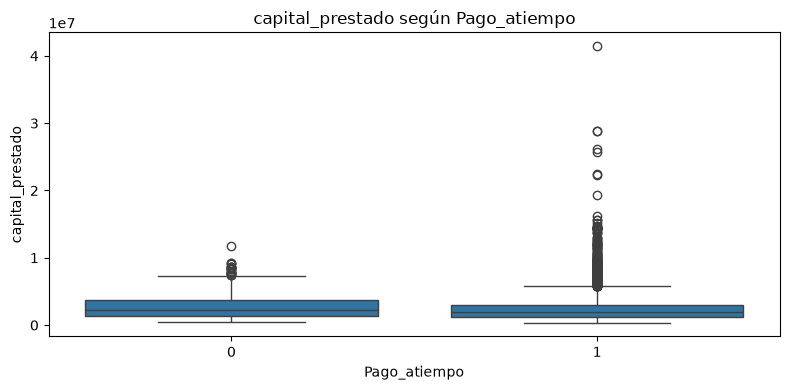

,count,mean,median,std,min,max
Pago_atiempo,,,,,,
0,511,"2,781,774.113","2,268,000.000","1,942,337.702","408,000.000","11,808,000.000"
1,10252,"2,416,996.273","1,908,446.400","1,906,438.413","360,000.000","41,444,152.800"


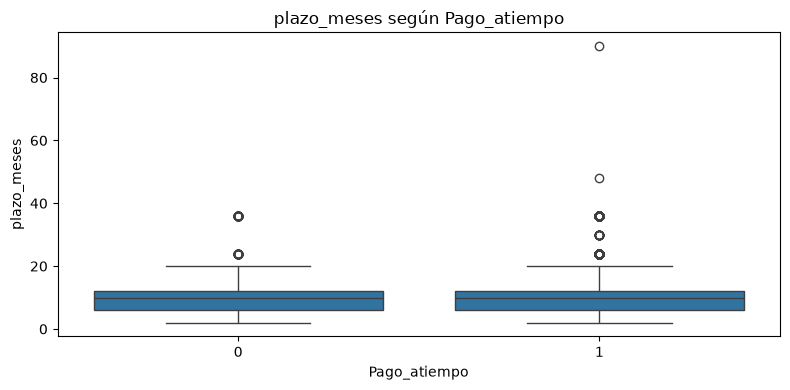

,count,mean,median,std,min,max
Pago_atiempo,,,,,,
0,511,12.450,10.000,9.274,2,36
1,10252,10.482,10.000,6.459,2,90


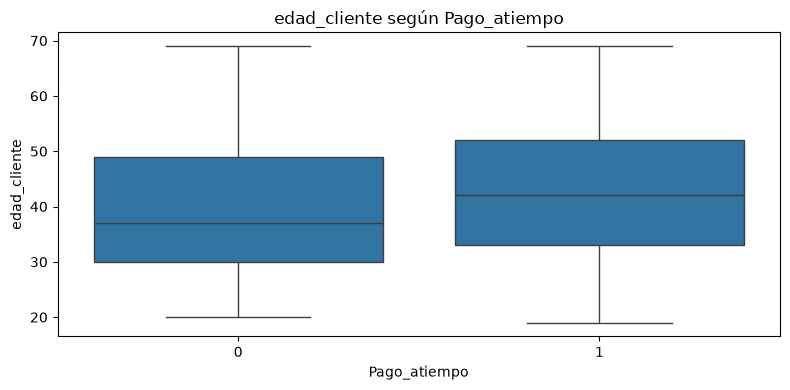

,count,mean,median,std,min,max
Pago_atiempo,,,,,,
0,500,40.008,37.000,12.346,20.000,69.000
1,10113,42.986,42.000,11.910,19.000,69.000


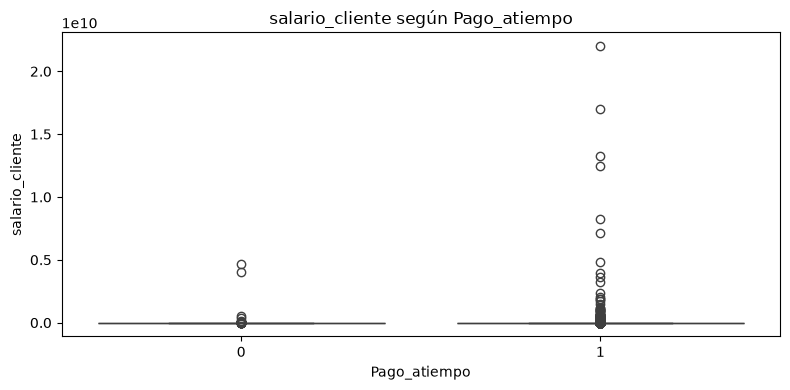

,count,mean,median,std,min,max
Pago_atiempo,,,,,,
0,511,"23,555,143.327","3,000,000.000","274,787,635.676",0,4663274549
1,10252,"16,900,485.131","3,000,000.000","359,032,091.871",0,22000000000


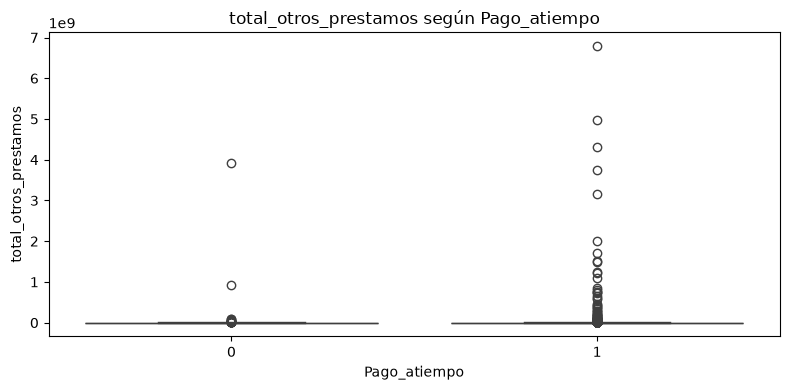

,count,mean,median,std,min,max
Pago_atiempo,,,,,,
0,511,"11,564,401.926","900,000.000","178,148,935.519",0,3918433000
1,10252,"5,973,424.175","1,000,000.000","114,636,297.605",0,6787675263


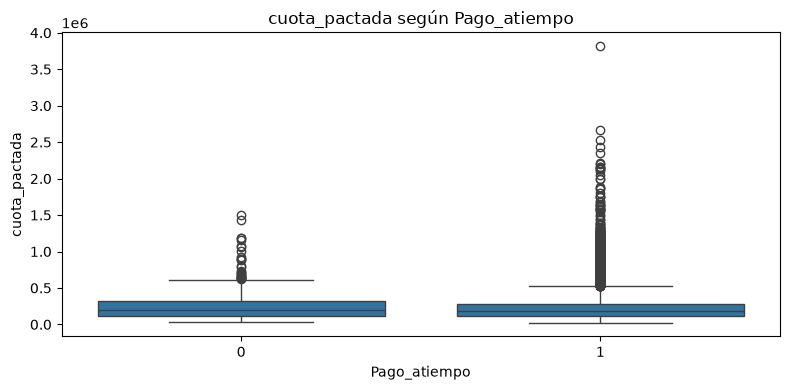

,count,mean,median,std,min,max
Pago_atiempo,,,,,,
0,511,"254,755.691","199,002.000","201,712.005",37586,1500131
1,10252,"243,062.231","182,576.000","210,915.902",23944,3816752


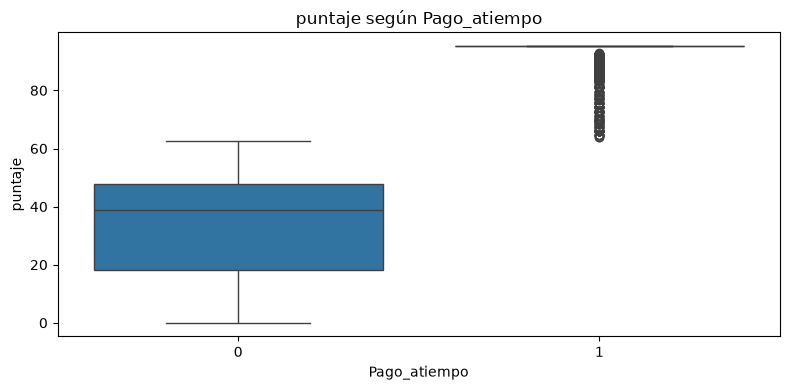

,count,mean,median,std,min,max
Pago_atiempo,,,,,,
0,376,35.323,38.883,18.467,0.051,62.668
1,10252,94.563,95.228,2.874,63.810,95.228


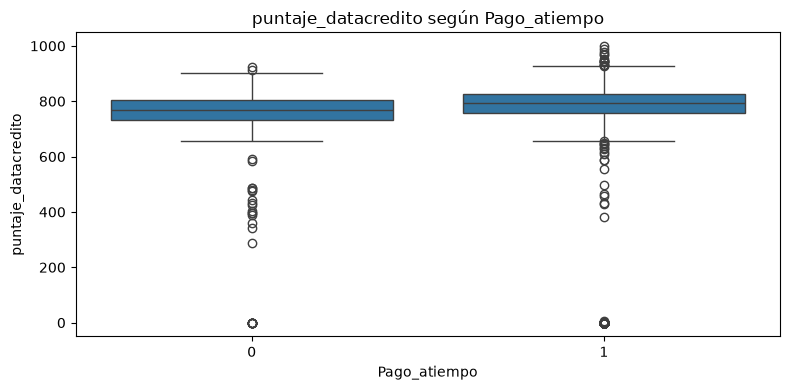

,count,mean,median,std,min,max
Pago_atiempo,,,,,,
0,510,748.880,768.000,130.914,0.000,922.000
1,10246,782.456,792.000,102.871,0.000,999.000


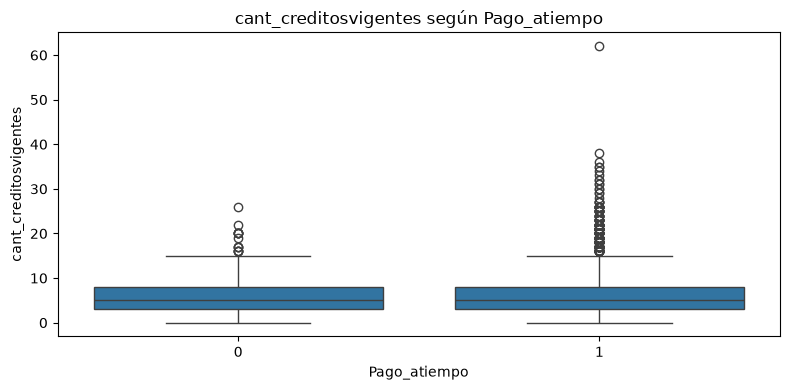

,count,mean,median,std,min,max
Pago_atiempo,,,,,,
0,511,5.569,5.000,4.138,0,26
1,10252,5.735,5.000,3.969,0,62


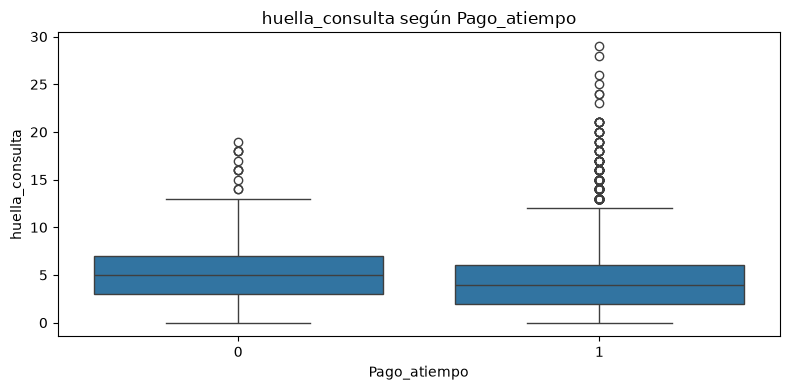

,count,mean,median,std,min,max
Pago_atiempo,,,,,,
0,511,5.241,5.000,3.451,0,19
1,10252,4.178,4.000,3.036,0,29


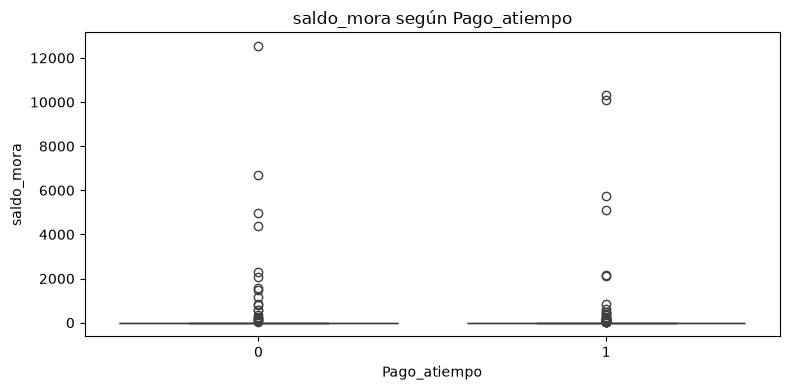

,count,mean,median,std,min,max
Pago_atiempo,,,,,,
0,500,82.368,0.000,722.556,0.000,"12,534.000"
1,10107,4.054,0.000,165.872,0.000,"10,327.000"


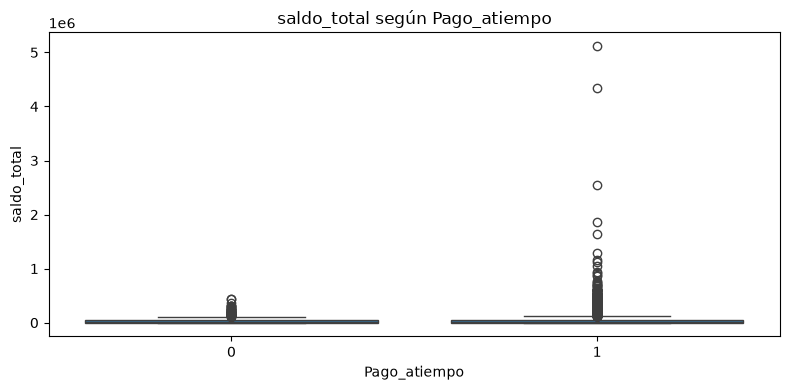

,count,mean,median,std,min,max
Pago_atiempo,,,,,,
0,500,"39,074.922","14,518.500","63,386.028",0.000,"445,295.000"
1,10107,"46,276.900","16,308.000","107,940.627",0.000,"5,116,066.000"


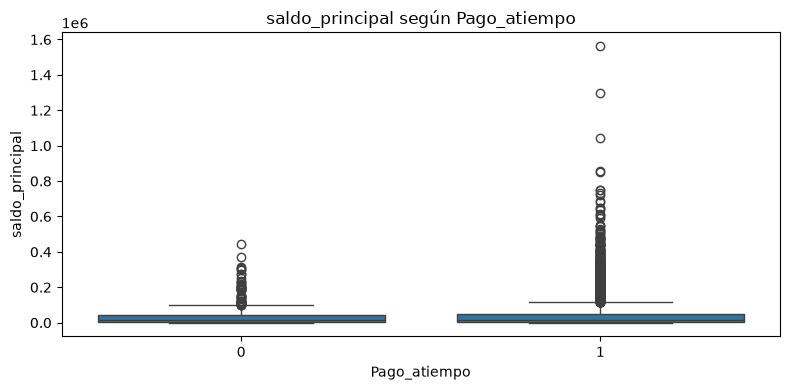

,count,mean,median,std,min,max
Pago_atiempo,,,,,,
0,482,"36,646.427","13,110.000","60,082.811",0.000,"445,295.000"
1,9876,"40,526.735","14,492.500","71,740.389",0.000,"1,562,285.000"


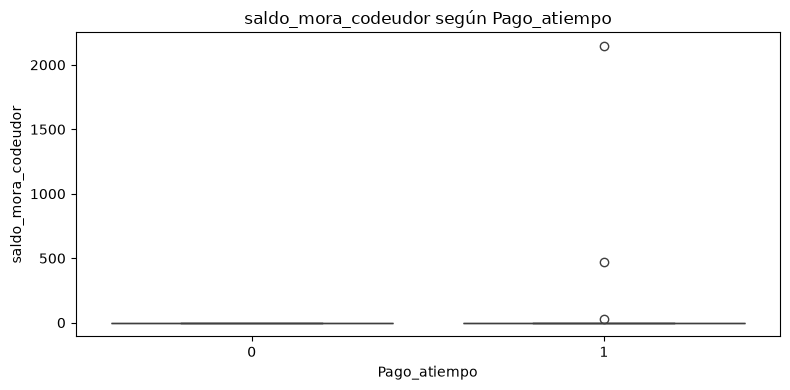

,count,mean,median,std,min,max
Pago_atiempo,,,,,,
0,471,0.000,0.000,0.000,0.000,0.000
1,9702,0.273,0.000,22.295,0.000,"2,145.000"


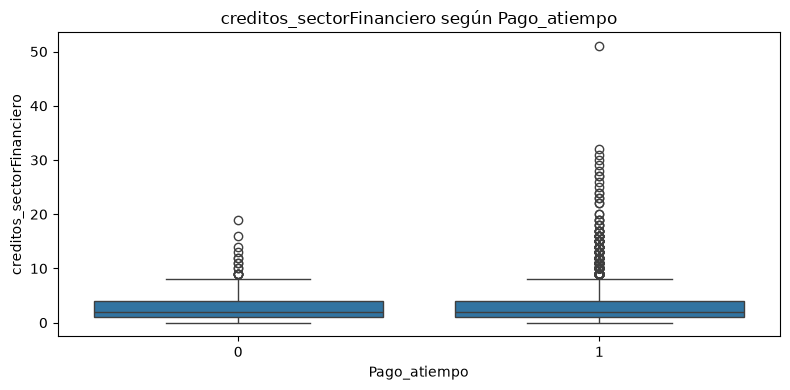

,count,mean,median,std,min,max
Pago_atiempo,,,,,,
0,511,2.517,2.000,2.645,0,19
1,10252,2.793,2.000,2.753,0,51


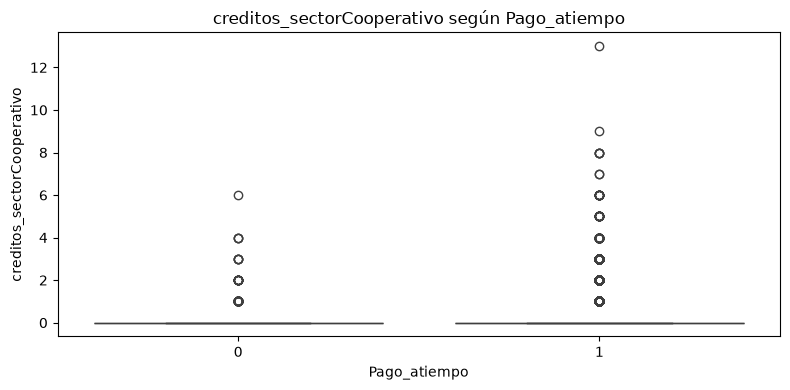

,count,mean,median,std,min,max
Pago_atiempo,,,,,,
0,511,0.202,0.000,0.620,0,6
1,10252,0.273,0.000,0.721,0,13


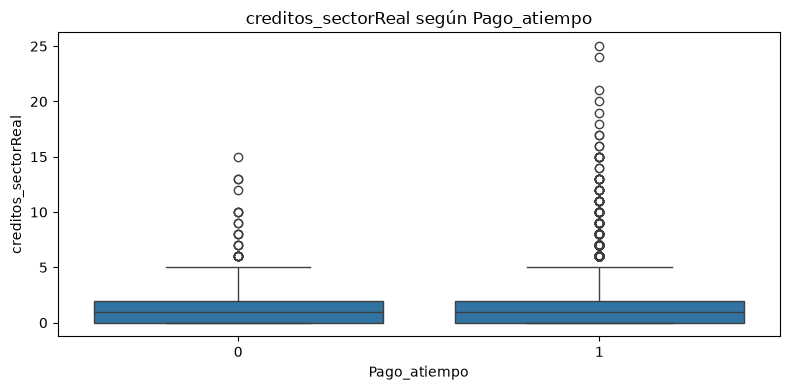

,count,mean,median,std,min,max
Pago_atiempo,,,,,,
0,511,1.493,1.000,2.055,0,15
1,10252,1.293,1.000,1.812,0,25


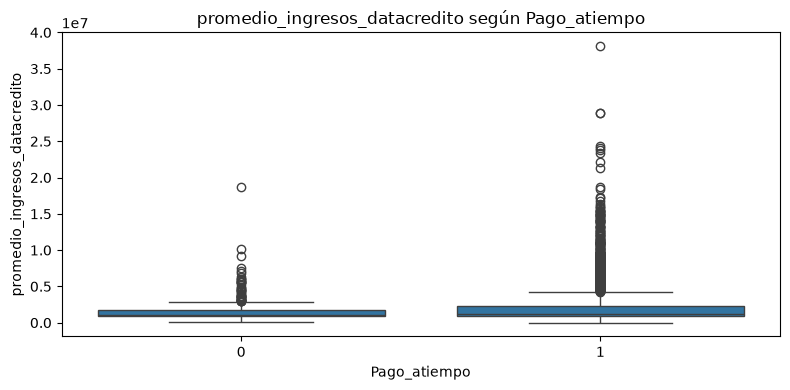

,count,mean,median,std,min,max
Pago_atiempo,,,,,,
0,343,"1,605,742.050","1,052,529.000","1,668,892.062","30,285.000","18,727,755.000"
1,7490,"2,023,447.768","1,211,296.000","2,161,702.283",0.000,"38,106,581.000"


In [11]:
for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_eda, x="Pago_atiempo", y=col)
    plt.title(f"{col} según Pago_atiempo")
    plt.tight_layout()
    plt.show()

    resumen = df_eda.groupby("Pago_atiempo", observed=False)[col].agg(
        ["count", "mean", "median", "std", "min", "max"]
    )
    display(resumen.round(3))



### Proporción de Pago_atiempo según tipo_credito


Pago_atiempo,0,1
tipo_credito,,
4,4.690,95.310
6,42.860,57.140
7,0.000,100.000
9,4.730,95.270
10,2.590,97.410
68,0.000,100.000


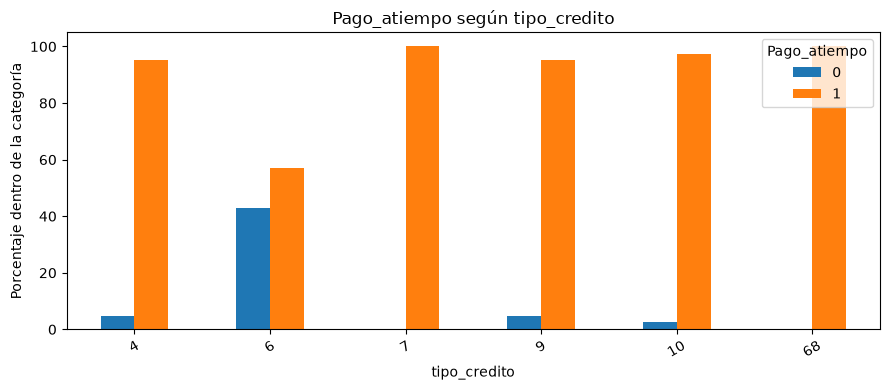


### Proporción de Pago_atiempo según tipo_laboral


Pago_atiempo,0,1
tipo_laboral,,
Empleado,4.290,95.710
Independiente,5.510,94.490


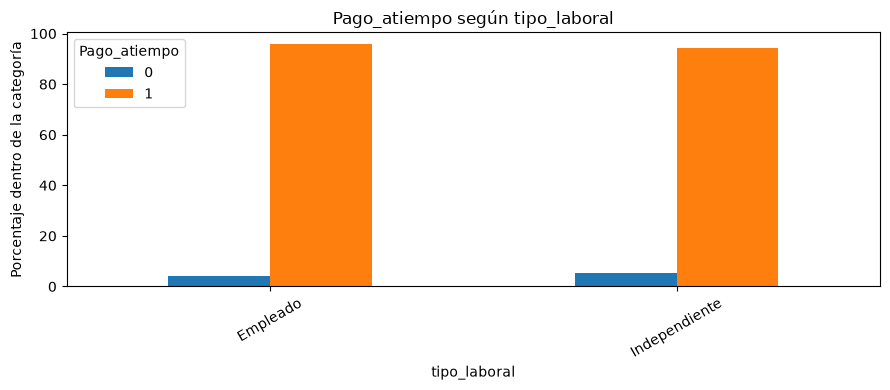


### Proporción de Pago_atiempo según tendencia_ingresos


Pago_atiempo,0,1
tendencia_ingresos,,
Creciente,3.910,96.090
Decreciente,6.270,93.730
Estable,4.630,95.370


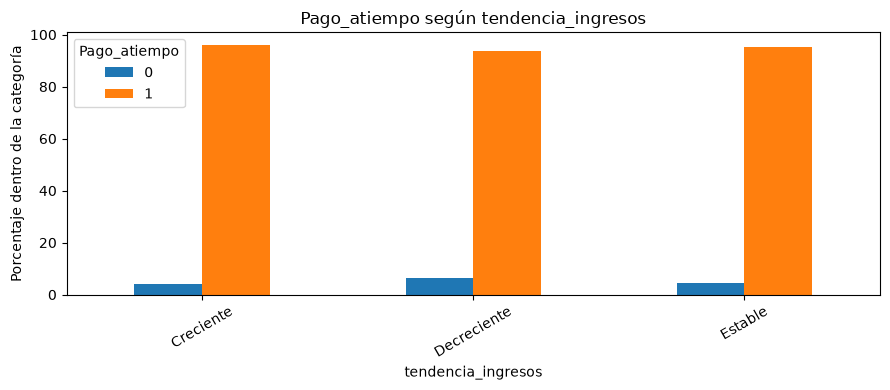

In [12]:
for col in ["tipo_credito", "tipo_laboral", "tendencia_ingresos"]:
    tabla = pd.crosstab(
        df_eda[col],
        df_eda["Pago_atiempo"],
        normalize="index"
    ) * 100

    print(f"\n### Proporción de Pago_atiempo según {col}")
    display(tabla.round(2))

    tabla.plot(kind="bar", figsize=(9, 4))
    plt.title(f"Pago_atiempo según {col}")
    plt.ylabel("Porcentaje dentro de la categoría")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


### Interpretación bivariable

Las variables que muestran diferencias claras entre las clases objetivo pueden ser candidatas a mayor relevancia predictiva. Sin embargo, una diferencia descriptiva no implica causalidad ni garantiza importancia en un modelo.

Debe prestarse especial atención a variables financieras, puntajes de riesgo, cantidad de créditos, saldos de mora y carga de cuotas, ya que conceptualmente pueden estar relacionadas con la capacidad de pago.

## 11. Análisis multivariable

Se estudian simultáneamente varias variables para identificar relaciones, redundancias y posibles problemas de multicolinealidad.

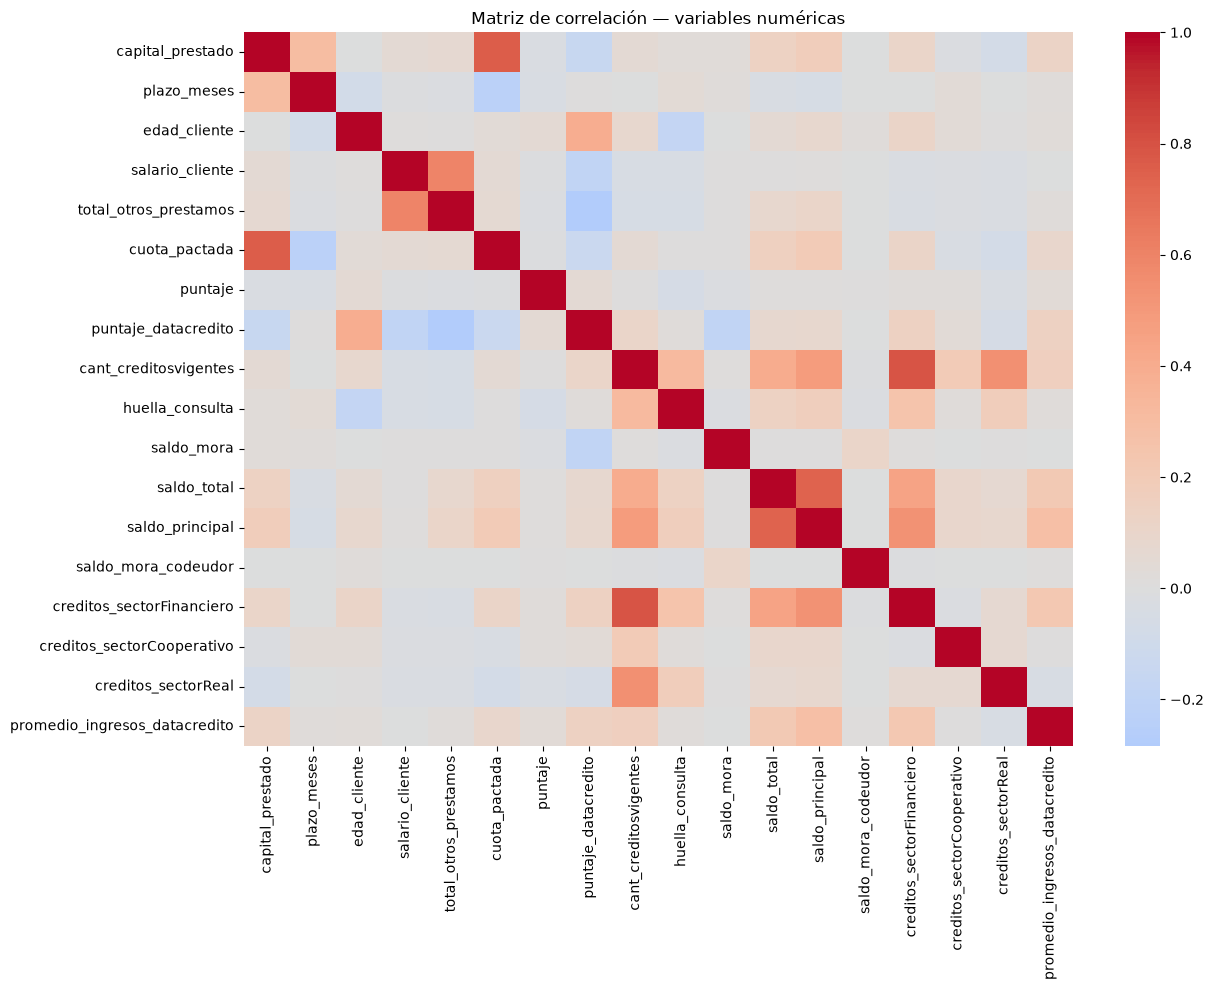

,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito
capital_prestado,1.000,0.300,-0.010,0.050,0.070,0.760,-0.030,-0.150,0.050,0.030,0.030,0.140,0.180,-0.010,0.110,-0.020,-0.080,0.120
plazo_meses,0.300,1.000,-0.080,-0.010,-0.010,-0.230,-0.030,0.000,-0.000,0.050,0.020,-0.030,-0.050,-0.000,-0.000,0.030,-0.000,0.020
edad_cliente,-0.010,-0.080,1.000,0.010,0.000,0.040,0.050,0.390,0.090,-0.180,-0.000,0.050,0.080,0.020,0.110,0.030,0.000,0.030
salario_cliente,0.050,-0.010,0.010,1.000,0.600,0.050,-0.010,-0.190,-0.040,-0.040,0.000,0.000,0.010,-0.000,-0.020,-0.010,-0.030,-0.000
total_otros_prestamos,0.070,-0.010,0.000,0.600,1.000,0.060,-0.010,-0.280,-0.050,-0.050,0.010,0.080,0.110,-0.000,-0.030,-0.010,-0.030,0.020
cuota_pactada,0.760,-0.230,0.040,0.050,0.060,1.000,-0.010,-0.130,0.050,0.000,0.000,0.150,0.200,-0.010,0.110,-0.030,-0.070,0.090
puntaje,-0.030,-0.030,0.050,-0.010,-0.010,-0.010,1.000,0.050,0.000,-0.060,-0.020,0.010,0.010,0.000,0.020,0.030,-0.030,0.040
puntaje_datacredito,-0.150,0.000,0.390,-0.190,-0.280,-0.130,0.050,1.000,0.100,0.020,-0.190,0.070,0.080,0.000,0.150,0.030,-0.050,0.140
cant_creditosvigentes,0.050,-0.000,0.090,-0.040,-0.050,0.050,0.000,0.100,1.000,0.320,0.010,0.400,0.490,-0.010,0.790,0.200,0.540,0.160
huella_consulta,0.030,0.050,-0.180,-0.040,-0.050,0.000,-0.060,0.020,0.320,1.000,-0.010,0.140,0.170,-0.020,0.250,0.020,0.170,0.020


In [13]:
# Matriz de correlación de Pearson para variables numéricas
corr = df_eda[columnas_numericas].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Matriz de correlación — variables numéricas")
plt.tight_layout()
plt.show()

display(corr.round(2))


### Interpretación de correlaciones

Las correlaciones altas entre variables pueden indicar información redundante. Por ejemplo, `saldo_total` y `saldo_principal` podrían estar relacionadas por definición; la matriz permite comprobar empíricamente si existe esa relación.

La correlación no implica causalidad. Además, las correlaciones lineales pueden ser bajas incluso cuando existe una relación no lineal.

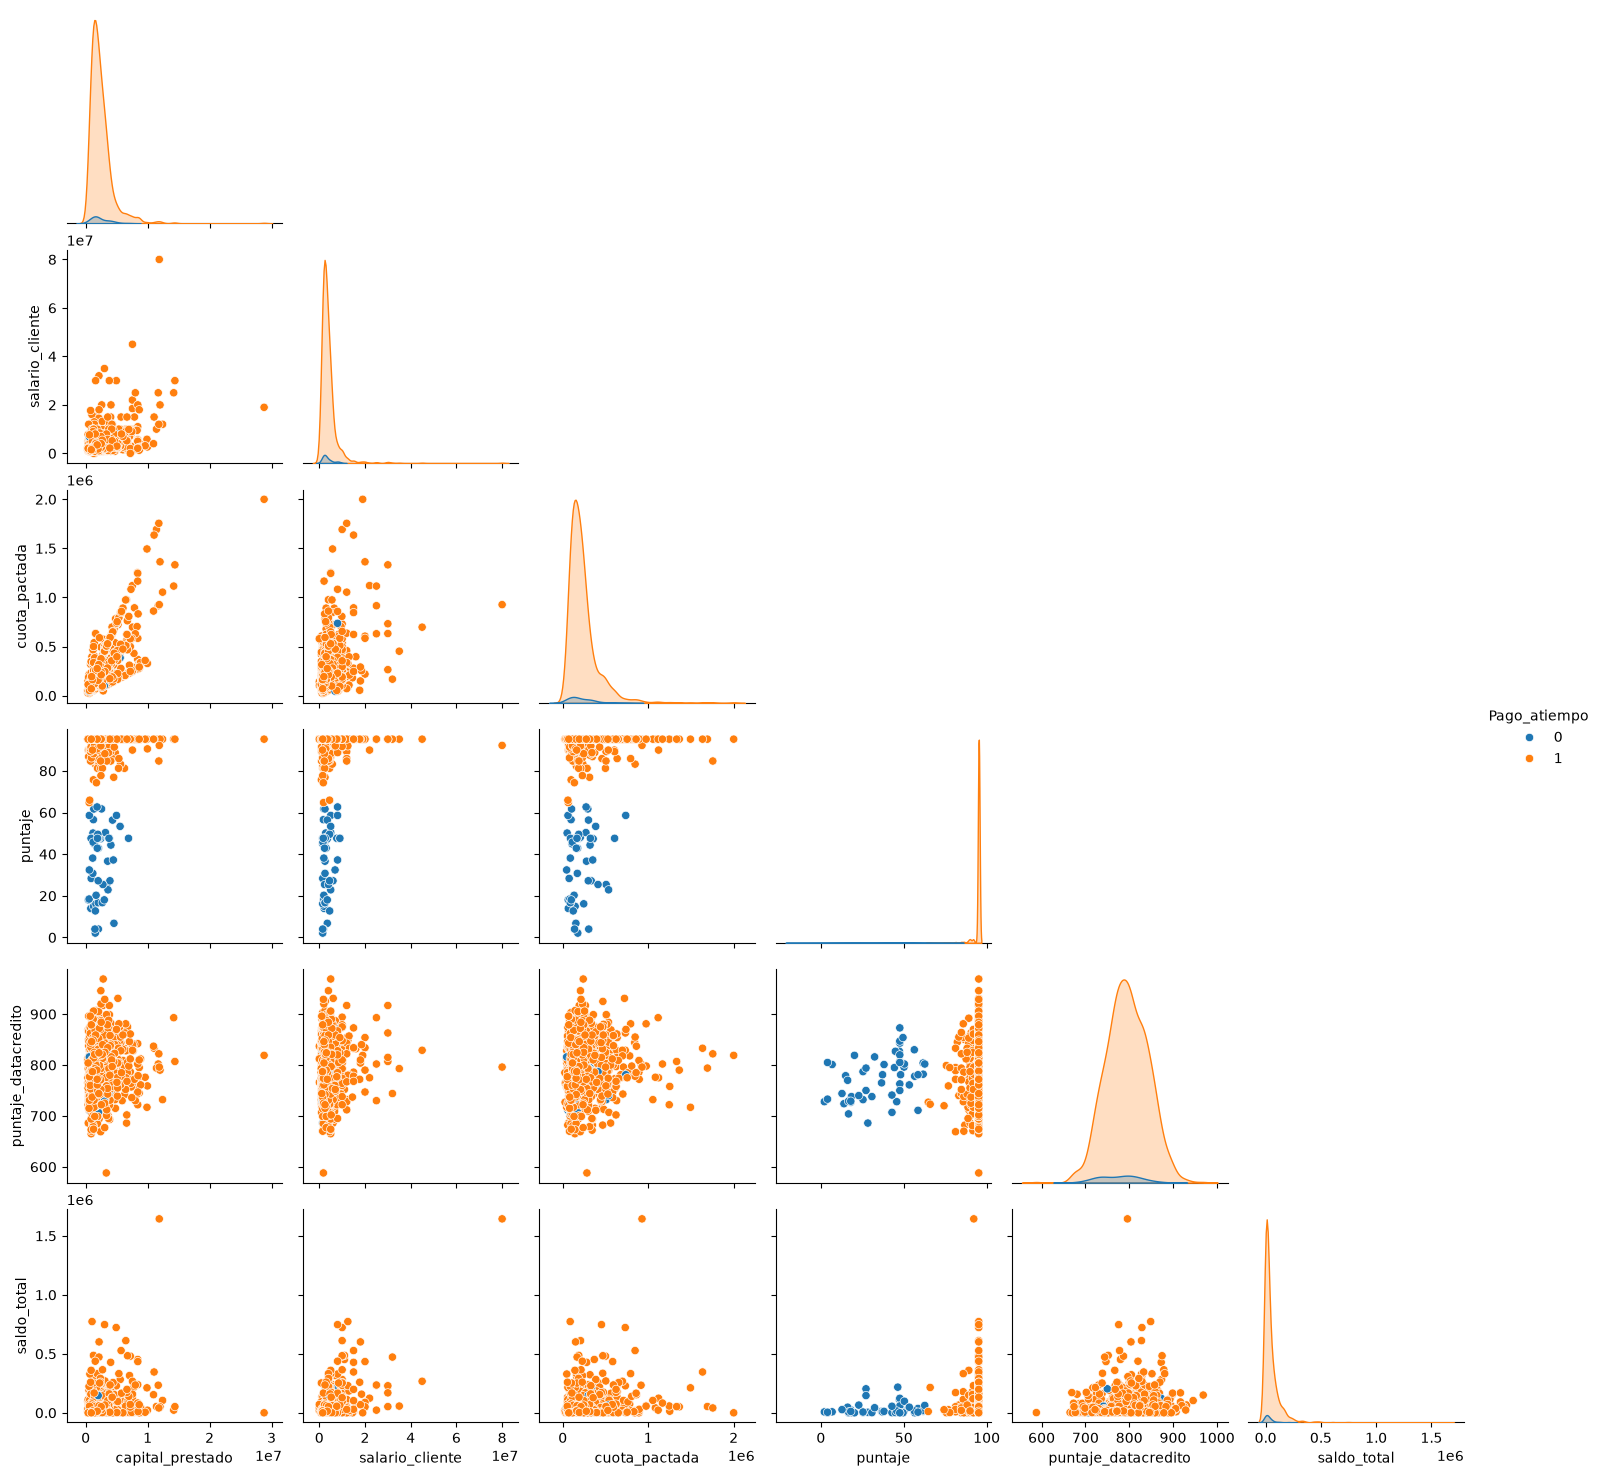

In [14]:
# Pairplot sobre una muestra para mantener el gráfico legible
cols_pairplot = [
    "capital_prestado",
    "salario_cliente",
    "cuota_pactada",
    "puntaje",
    "puntaje_datacredito",
    "saldo_total",
    "Pago_atiempo"
]

muestra = df_eda[cols_pairplot].dropna().sample(
    min(1500, len(df_eda[cols_pairplot].dropna())),
    random_state=42
)

sns.pairplot(muestra, hue="Pago_atiempo", corner=True)
plt.show()


## 12. Relaciones entre variables y posible multicolinealidad

Además de la correlación, conviene observar relaciones conceptuales:

- `capital_prestado` y `cuota_pactada` pueden relacionarse con el `plazo_meses`.
- `salario_cliente` y `promedio_ingresos_datacredito` representan medidas de ingresos y pueden contener información redundante.
- `saldo_total`, `saldo_principal` y `saldo_mora` describen componentes de endeudamiento.
- Los créditos por sector pueden estar relacionados con `cant_creditosvigentes`.

Estas relaciones deberán revisarse antes del modelado para evitar duplicidad de información o variables derivadas de otras variables de forma no deseada.

## 13. Reglas de validación derivadas del EDA

A partir de la estructura observada, se proponen reglas iniciales. Estas reglas deben validarse con el conocimiento de negocio antes de aplicarse como restricciones definitivas.

In [15]:
reglas_validacion = pd.DataFrame([
    ["fecha_prestamo", "Debe ser una fecha válida", "Evitar registros temporales corruptos"],
    ["edad_cliente", "18 <= edad <= 100", "Rango razonable de edad adulta"],
    ["capital_prestado", "capital_prestado > 0", "Un préstamo debe tener capital positivo"],
    ["plazo_meses", "plazo_meses > 0", "El plazo debe ser positivo"],
    ["salario_cliente", "salario_cliente >= 0", "El ingreso no puede ser negativo"],
    ["total_otros_prestamos", "total_otros_prestamos >= 0", "La deuda no puede ser negativa"],
    ["cuota_pactada", "cuota_pactada > 0", "Una cuota pactada debe ser positiva"],
    ["puntaje", "0 <= puntaje <= 100", "Escala observada"],
    ["puntaje_datacredito", "0 <= puntaje_datacredito <= 999", "Escala observada"],
    ["cant_creditosvigentes", "cant_creditosvigentes >= 0", "Cantidad no negativa"],
    ["huella_consulta", "huella_consulta >= 0", "Cantidad no negativa"],
    ["saldo_mora", "saldo_mora >= 0", "Saldo monetario no negativo"],
    ["saldo_total", "saldo_total >= 0", "Saldo monetario no negativo"],
    ["saldo_principal", "saldo_principal >= 0", "Saldo monetario no negativo"],
    ["saldo_mora_codeudor", "saldo_mora_codeudor >= 0", "Saldo monetario no negativo"],
    ["creditos_sectorFinanciero", ">= 0 y entero", "Cantidad de créditos"],
    ["creditos_sectorCooperativo", ">= 0 y entero", "Cantidad de créditos"],
    ["creditos_sectorReal", ">= 0 y entero", "Cantidad de créditos"],
    ["Pago_atiempo", "Solo 0 o 1", "Variable objetivo dicotómica"],
    ["tendencia_ingresos", "Creciente/Decreciente/Estable o nulo", "Categorías válidas observadas"],
], columns=["variable", "regla", "justificación"])

display(reglas_validacion)


,variable,regla,justificación
0,fecha_prestamo,Debe ser una fecha válida,Evitar registros temporales corruptos
1,edad_cliente,18 <= edad <= 100,Rango razonable de edad adulta
2,capital_prestado,capital_prestado > 0,Un préstamo debe tener capital positivo
3,plazo_meses,plazo_meses > 0,El plazo debe ser positivo
4,salario_cliente,salario_cliente >= 0,El ingreso no puede ser negativo
5,total_otros_prestamos,total_otros_prestamos >= 0,La deuda no puede ser negativa
6,cuota_pactada,cuota_pactada > 0,Una cuota pactada debe ser positiva
7,puntaje,0 <= puntaje <= 100,Escala observada
8,puntaje_datacredito,0 <= puntaje_datacredito <= 999,Escala observada
9,cant_creditosvigentes,cant_creditosvigentes >= 0,Cantidad no negativa


### 13.1 Implementación de controles de calidad

Los controles siguientes sirven como punto de partida para automatizar la validación en futuras cargas.

In [16]:
def reporte_validacion(data):
    resultados = {
        "edad_fuera_de_rango": int((data["edad_cliente"].notna() & ~data["edad_cliente"].between(18, 100)).sum()),
        "capital_no_positivo": int((data["capital_prestado"] <= 0).sum()),
        "plazo_no_positivo": int((data["plazo_meses"] <= 0).sum()),
        "salario_negativo": int((data["salario_cliente"] < 0).sum()),
        "cuota_no_positiva": int((data["cuota_pactada"] <= 0).sum()),
        "puntaje_fuera_0_100": int((data["puntaje"].notna() & ~data["puntaje"].between(0, 100)).sum()),
        "datacredito_fuera_0_999": int((data["puntaje_datacredito"].notna() & ~data["puntaje_datacredito"].between(0, 999)).sum()),
        "target_distinto_0_1": int((~data["Pago_atiempo"].astype("string").isin(["0", "1"])).sum()),
    }
    return pd.Series(resultados)

# Sobre la base original se observan los problemas antes de la limpieza.
display(reporte_validacion(df))


edad_fuera_de_rango        150
capital_no_positivo          0
plazo_no_positivo            0
salario_negativo             0
cuota_no_positiva            0
puntaje_fuera_0_100        135
datacredito_fuera_0_999      1
target_distinto_0_1          0
dtype: int64

## 14. Transformaciones potenciales

No todas las transformaciones deben aplicarse en este notebook. Algunas dependen del algoritmo que se utilice posteriormente.

### Transformaciones candidatas

1. **Variables monetarias sesgadas:** evaluar `log1p` para `capital_prestado`, `salario_cliente`, `total_otros_prestamos`, saldos y `promedio_ingresos_datacredito`.
2. **Escalado:** modelos sensibles a escala pueden requerir StandardScaler o RobustScaler.
3. **Variables categóricas:** aplicar one-hot encoding u otra codificación según el algoritmo.
4. **Valores faltantes:** definir imputación en función de la naturaleza de cada variable y evitando fuga de información.
5. **Outliers:** comparar modelos con y sin tratamiento; no eliminarlos sin justificación de negocio.
6. **Fecha:** extraer componentes temporales si son relevantes.
7. **Desbalance de clases:** evaluar estrategias como class weights o técnicas de muestreo durante el modelado.

## 15. Atributos derivados potencialmente útiles

A partir de las variables disponibles pueden construirse indicadores de capacidad de pago, endeudamiento y comportamiento crediticio. Se crean algunos como variables exploratorias; su utilidad debe comprobarse posteriormente.

In [17]:
df_features = df_eda.copy()

# Componentes temporales
df_features["anio_prestamo"] = df_features["fecha_prestamo"].dt.year
df_features["mes_prestamo"] = df_features["fecha_prestamo"].dt.month
df_features["dia_semana_prestamo"] = df_features["fecha_prestamo"].dt.dayofweek

# Indicadores financieros
df_features["cuota_sobre_salario"] = np.where(
    df_features["salario_cliente"] > 0,
    df_features["cuota_pactada"] / df_features["salario_cliente"],
    np.nan
)

df_features["deuda_sobre_salario"] = np.where(
    df_features["salario_cliente"] > 0,
    (
        df_features["total_otros_prestamos"]
        + df_features["saldo_total"].fillna(0)
    ) / df_features["salario_cliente"],
    np.nan
)

df_features["capital_sobre_salario"] = np.where(
    df_features["salario_cliente"] > 0,
    df_features["capital_prestado"] / df_features["salario_cliente"],
    np.nan
)

df_features["total_creditos_sector"] = (
    df_features["creditos_sectorFinanciero"].fillna(0)
    + df_features["creditos_sectorCooperativo"].fillna(0)
    + df_features["creditos_sectorReal"].fillna(0)
)

df_features["tiene_mora"] = (
    df_features["saldo_mora"].fillna(0) > 0
).astype("int8")

display(df_features[
    [
        "cuota_sobre_salario",
        "deuda_sobre_salario",
        "capital_sobre_salario",
        "total_creditos_sector",
        "tiene_mora"
    ]
].describe().T)


,count,mean,std,min,25%,50%,75%,max
cuota_sobre_salario,"10,739.000",0.095,1.243,0.000,0.039,0.061,0.095,125.802
deuda_sobre_salario,"10,739.000",0.703,24.641,0.000,0.221,0.353,0.489,"2,498.583"
capital_sobre_salario,"10,739.000",0.922,8.342,0.000,0.370,0.633,1.021,840.000
total_creditos_sector,"10,763.000",4.353,3.489,0.000,2.000,4.000,6.000,60.000
tiene_mora,"10,763.000",0.005,0.071,0.000,0.000,0.000,0.000,1.000


## 16. Conclusiones del EDA

### Calidad y estructura

- La base contiene **10.763 registros y 23 variables**.
- Existen variables numéricas, categóricas, temporales y una variable objetivo binaria.
- Se detectaron valores nulos principalmente en variables relacionadas con información de Datacrédito y tendencia de ingresos.
- No se encontraron filas completamente duplicadas.

### Inconsistencias

Se detectaron valores sospechosos que requieren validación, entre ellos edades superiores a 100 años, un plazo de 90 meses aislado, un código de tipo de crédito aislado (`68`), puntajes negativos y valores no categóricos dentro de `tendencia_ingresos`.

Se conservan el código 68 y los plazos largos. Los rangos de edad y puntajes se aplican únicamente a la vista exploratoria, de manera provisional. La base original permanece intacta.

### Distribuciones

Las variables monetarias presentan potencial de fuerte asimetría y valores extremos. Por ello, la mediana, el IQR y las transformaciones logarítmicas deben considerarse además de la media.

### Variable objetivo

`Pago_atiempo` presenta un marcado desbalance de clases, por lo que el modelado posterior debe evitar depender exclusivamente de accuracy.

### Relaciones

Las variables financieras, los puntajes, la mora y la cantidad de créditos son candidatas naturales para explicar diferencias en el comportamiento de pago. La matriz de correlación permite además identificar variables potencialmente redundantes.

### Próximos pasos

1. Validar las reglas de calidad con conocimiento de negocio.
2. Definir una estrategia formal de imputación.
3. Evaluar transformaciones de variables sesgadas.
4. Codificar variables categóricas.
5. Analizar el desbalance de la variable objetivo.
6. Evaluar los atributos derivados propuestos.
7. Separar correctamente entrenamiento y prueba antes de realizar transformaciones aprendidas de los datos.

> **Conclusión:** el EDA no solo describe la base, sino que deja documentadas las decisiones de limpieza, las anomalías encontradas, las reglas de validación y las transformaciones que pueden utilizarse en las siguientes etapas del proyecto.

## 17. Hallazgos cuantificados y alcance

Esta sección calcula hallazgos sobre la base original para que puedan contrastarse con las conclusiones. Los patrones son asociaciones descriptivas, no relaciones causales ni prueba de disponibilidad temporal.

El notebook original exploraba la base completa. Por lo tanto, aunque el entrenamiento corregido separa los períodos y no selecciona modelos con test, ese período ya tuvo exposición exploratoria. Se presenta como evaluación retrospectiva y no como una validación externa completamente inédita. Hace falta un período nuevo para esa validación.

Las features exploratorias de la sección 15 son propuestas; las realmente usadas por la API y el entrenamiento están centralizadas en `ft_engineering.py`. `puntaje` está excluido preventivamente por posible fuga, pendiente de confirmar su origen. No se agrega al modelo por mostrar una relación fuerte en este EDA.


La base tiene **10,763 registros**, **23 columnas**, **0 duplicados completos** y **4.75% de no pago**.

,porcentaje_nulos
tendencia_ingresos,27.241
promedio_ingresos_datacredito,27.223
saldo_mora_codeudor,5.482
saldo_principal,3.763
saldo_mora,1.449


,correlacion_con_pago
puntaje,0.923
huella_consulta,-0.074
saldo_mora,-0.073
puntaje_datacredito,0.068
plazo_meses,-0.063
capital_prestado,-0.041
promedio_ingresos_datacredito,0.040
edad_cliente,0.032


,registros,casos_no_pago,tasa_no_pago
mes,,,
2024-11,186,13,0.070
2024-12,1216,74,0.061
2025-01,1917,86,0.045
2025-02,1094,64,0.059
2025-03,1115,57,0.051
2025-04,1102,69,0.063
2025-05,1083,47,0.043
2025-06,665,25,0.038
2025-07,644,20,0.031


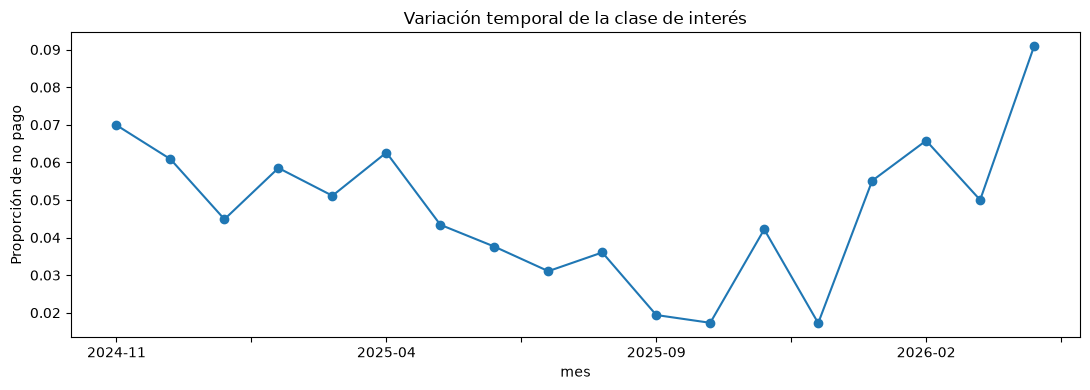

In [18]:
from IPython.display import Markdown
missing = (df.isna().mean()*100).sort_values(ascending=False)
rate = (pd.to_numeric(df["Pago_atiempo"], errors="coerce")==0).mean()
display(Markdown(f"La base tiene **{len(df):,} registros**, **{df.shape[1]} columnas**, "
                 f"**{df.duplicated().sum()} duplicados completos** y **{rate:.2%} de no pago**."))
display(missing.head(5).rename("porcentaje_nulos").to_frame())
numeric_original = df.select_dtypes(include="number")
correlations = numeric_original.corr()["Pago_atiempo"].drop("Pago_atiempo")
display(correlations.reindex(correlations.abs().sort_values(ascending=False).index).head(8).to_frame("correlacion_con_pago"))
monthly = df.assign(fecha=pd.to_datetime(df["fecha_prestamo"], errors="coerce"))
monthly["mes"] = monthly["fecha"].dt.to_period("M").astype(str)
monthly["no_pago"] = (monthly["Pago_atiempo"]==0).astype(int)
monthly_summary = monthly.groupby("mes")["no_pago"].agg(["count", "sum", "mean"])
display(monthly_summary.rename(columns={"count":"registros", "sum":"casos_no_pago", "mean":"tasa_no_pago"}))
fig, ax = plt.subplots(figsize=(11,4))
monthly_summary["mean"].plot(marker="o", ax=ax)
ax.set_ylabel("Proporción de no pago")
ax.set_title("Variación temporal de la clase de interés")
plt.tight_layout(); plt.show()
(ROOT/"reports").mkdir(exist_ok=True)
monthly_summary.to_csv(ROOT/"reports/eda_tasas_mensuales.csv")
